# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [3]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [13]:
def fan_in_fan_out(weight: torch.Tensor) -> tuple[int, int]:
    """Compute (fan_in, fan_out) for a weight tensor."""
    ndim = weight.ndim
    if ndim != 1 and ndim != 2:
        raise TypeError("The weights matrix of a linear layer must be of shape (x,y) or (x,)")

    x = weight.shape[0]
    if ndim == 1:
        return (x, 1)

    return (x, weight.shape[1])

In [57]:
import math

def kaiming_uniform_(weight: torch.Tensor, nonlinearity: str = "relu") -> torch.Tensor:
    """
    In-place Kaiming/He uniform init.

    Follow this common choice:
      gain = sqrt(2) for ReLU
      std = gain / sqrt(fan_in)
      bound = sqrt(3) * std
      U(-bound, bound)
    """
    fan_in, fan_out = fan_in_fan_out(weight)
    
    gain = math.sqrt(2)
    std = gain / math.sqrt(fan_in)
    bound = math.sqrt(3) * std
    weight.uniform_(-bound, bound)

    return weight

In [61]:
# CREATING A LINEAR LAYER, initialize with kaimig_uniform_, bias initialized w zeros

class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.W = nn.Parameter(kaiming_uniform_(torch.empty(out_features, in_features)))
        self.b = nn.Parameter(torch.zeros(out_features)) if bias else None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        out = x @ self.W.T ## .T dreturns a view
        if self.b is not None:
            out = out + self.b ## reassignment
        return out

In [69]:

## say num_embeddings = 3 => weights provides "lookup" for 1,2,3
## W: (num_embeddings, embedding_dim)
## if idx: (B, T), self.weight[idx] returns (B, T, embedding_dim) where each int64 in T is replaced with corresponding row vector (embedding)
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.W = nn.Parameter(kaiming_uniform_(torch.zeros(num_embeddings, embedding_dim)))
        print(self.W.shape)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.W[idx]

In [71]:
## Initializing a Dropout LAYER
## Inference: like it's not there
## Training: drop out individual values of x 

class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if not self.training:
            return x
        mask = (torch.rand_like(x) > self.p) ## samples ~U [0, 1) in same shape as x d
        return mask * x / (1-self.p)

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [87]:
## elementwise_affine ~ apply per-feature scale and shift (weight, bias)
## weight and bias each have shape (D,), D := feature dimension. 
## (EACH MOST NESTED ELEMENT OF x) = [x_1, ..., x_D] 
## normalize each of these most nested elements (feature dimension)
## simplifying assumption - just let self.D = normalized_shape. don't double check any of this.

class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        ## LayerNorm conventionally initialzes weight to ones and bias to zeros
        self.W = nn.Parameter(torch.ones(normalized_shape))
        self.b = nn.Parameter(torch.zeros(normalized_shape))

    ## not in place, returns a new tensor. First normalizes and then applies element-wise weight and bias (sort of part of the normalization)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        out = (x - mean) / torch.sqrt(var + self.eps)
        return out * self.W + self.b

layerNorm = LayerNorm(2)
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
layerNorm.forward(x)

tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<AddBackward0>)

In [89]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.eps = eps
        self.W = nn.Parameter(torch.ones(normalized_shape))
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        mean = (x**2).mean(dim=-1, keepdim=True)
        out = x / torch.sqrt(mean + self.eps)
        return out * self.W

rmsNorm = RMSNorm(2)
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
layerNorm.forward(x)

tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<AddBackward0>)

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [119]:
## in_dim -> hidden_dim -> hidden_dim -> ... -> out_dim
## depth = # all hidden_dims + 1 (out_dim)

def block(in_dim: int, out_dim: int) -> List[nn.Module]:
    linear = Linear(in_dim, out_dim)
    nonlinear = nn.GELU()
    norm = LayerNorm(out_dim)

    return [linear, nonlinear, norm]

class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()

        net_list = [*block(in_dim, hidden_dim)]
        
        for i in range(depth): # [0, depth)
            net_list.extend(block(hidden_dim, hidden_dim))

        net_list.extend(block(hidden_dim, out_dim))

        self.network = nn.Sequential(*net_list)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

mlp = MLP(6, 10, 6, 1)
x = torch.tensor([1, 2, 5, 6, 7, 10], dtype=torch.float32)
y = mlp.forward(x)
print(x)
print(y)

tensor([ 1.,  2.,  5.,  6.,  7., 10.])
tensor([ 1.1183,  0.9609,  0.1760, -1.3040, -1.3818,  0.4306],
       grad_fn=<AddBackward0>)


In [111]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """
## ATTN - this is not super like standard or anything just created a network
    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.network = nn.Sequential(
            *block(d_model, d_ff),
            *block(d_ff,d_model)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

ff = FeedForward(6)
x = torch.tensor([1, 2, 5, 6, 7, 10], dtype=torch.float32)
y = ff.forward(x)
print(x)
print(y)

tensor([ 1.,  2.,  5.,  6.,  7., 10.])
tensor([-0.2792, -0.2452, -1.0820, -0.3690,  2.1283, -0.1530],
       grad_fn=<AddBackward0>)


In [121]:
## ASSUMES out_dim of fn == in_dim of x

class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        # return x + fn(x, ...)
        return x + self.fn(x)

#res = Residual(ff)
res = Residual(mlp)
x = torch.tensor([1, 2, 5, 6, 7, 10], dtype=torch.float32)
y = res.forward(x)
print(x)
print(y)

tensor([ 1.,  2.,  5.,  6.,  7., 10.])
tensor([ 2.1183,  2.9609,  5.1760,  4.6960,  5.6182, 10.4306],
       grad_fn=<AddBackward0>)


## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [123]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [255]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

## type(train_ds) = type(test_ds) = torchvision.datasets.mnist.MNIST
train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

In [275]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    e.g.
    batch: 3
    C: 2 (binary classifier)
    logits: [[3, 4], [1, 3], [-4, 3]]
    targets: [0, 0, 1] (values in [, C)

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    ## log-softmax ~ -log({softmaxed "probability" of correct class}) = -log(e^{x_{y_i}}/sum_j(e^{x_{y_j}})) where i y_i is index of correct class
    ## targets[i] = index of correct class

    # for example i
    # Numerically stable softmax for correct class = g = e^(logits[i][targets[i]]) / sum_j (e^[i][j])
    logits_ms = logits - logits.max(dim=-1, keepdim=True).values
    """
    print(logits_ms)
    print(targets)
    print(torch.exp(logits_ms[torch.arange(logits_ms.shape[0]), targets])) # e^(softmax of correct class), (B,)
    print(torch.exp(logits_ms).sum(dim=-1)) # sum_j (e^[i][j]), (B,)
    """
    stable_softmax = torch.exp(logits_ms[torch.arange(logits_ms.shape[0]), targets]) / torch.exp(logits_ms).sum(dim=-1)
    return (-(stable_softmax.log())).mean()

"""
# little test
torch.manual_seed(3)
logits = torch.randn(3, 2) ## 3 batches giving predictions for 1/2 classes
targets = torch.randint(0, 2, (3,)) ## random ints [0, 10) in shape (2,)
actual = cross_entropy_from_logits(logits, targets)
"""


'\n# little test\ntorch.manual_seed(3)\nlogits = torch.randn(3, 2) ## 3 batches giving predictions for 1/2 classes\ntargets = torch.randint(0, 2, (3,)) ## random ints [0, 10) in shape (2,)\nactual = cross_entropy_from_logits(logits, targets)\n'

In [223]:
def test_cross_entropy_from_logits():
    # Compare against torch.nn.functional.cross_entropy (the reference)
    torch.manual_seed(0)
    logits = torch.randn(8, 10) ## 8 batches giving predictions for 1/10 classes
    targets = torch.randint(0, 10, (8,)) ## random ints [0, 10) in shape (8,)

    expected = torch.nn.functional.cross_entropy(logits, targets)
    actual = cross_entropy_from_logits(logits, targets)

    assert torch.allclose(actual, expected, atol=1e-6), f"Expected {expected}, got {actual}"
    print("test_cross_entropy_from_logits passed")

test_cross_entropy_from_logits()

tensor([0.0873, 0.1417, 0.0931, 0.0819, 0.1201, 0.0148, 0.4307, 0.0549])
tensor([-2.4382, -1.9542, -2.3737, -2.5018, -2.1197, -4.2102, -0.8425, -2.9031])
test_cross_entropy_from_logits passed


In [227]:
## couldn't find any other directions, so this ClassificationHead is just a linear layer

class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.head = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.head.forward(x)

In [243]:
### DEFINE NETWORK
## each digit image is (1, 28, 28) -flatten-> (784,), values in [1, 0]
class CustomNetwork(nn.Module):
    def __init__(self, in_dim: int = 784):
        super().__init__()
        mlp1 = MLP(in_dim, 200, 100, 2) 
        mlp2 = MLP(100, 50, 20, 2)
        ch = ClassificationHead(20, 10)

        self.network = nn.Sequential(mlp1, mlp2, ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = x.flatten(1, -1) # (B, ...) -> (B, x)
        return self.network(out)

In [393]:
def accuracy(loader: DataLoader, model: nn.Module):
    preds = []
    grounds = []
    for x, target in loader:
        y = model.forward(x)
        preds.append(y.argmax(dim=-1))
        grounds.append(target)

    correct = sum(xi == yi for xi, yi in zip(preds, grounds))
    accuracy = correct / len(preds)
    print(accuracy)

In [380]:
import torch.optim as optim

def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr
    )
    
    training_losses = []
    
    for epoch in range(epochs):
        model.train()
        for x, y in train_data_loader:
            optimizer.zero_grad()
            logits = model.forward(x)
            loss = cross_entropy_from_logits(logits, y)
            training_losses.append(loss)
            loss.backward()
            optimizer.step()
        model.eval()
        accuracy(test_data_loader, model)
            
    return training_losses
    

## WRITE EVALUATION CODE
## TRAIN/INFERENCE MODE
## WRITE SOME INFERENCE CODE
## OPTIMIZER STEPS + OPTIMIZER STEP SCHEMES
## NEXT STEPS: DROP OUT, OTHER TYPES OF STUFF, OTHER SIZES
## lr 1e-8
## #weight_decay=0.01


In [395]:
## TRAIN NETWORK

## HP
batch_size = 32

network = CustomNetwork()
train_dl = DataLoader(train_ds, batch_size = batch_size, shuffle=True)
test_dl = DataLoader(test_ds)

losses = train_classifier(network,
                          train_dl,
                          test_dl,
                          0.001, #lr
                          10, #epochs
                          42)

tensor([0.9570])
tensor([0.9602])
tensor([0.9719])
tensor([0.9705])
tensor([0.9660])
tensor([0.9757])
tensor([0.9735])
tensor([0.9772])
tensor([0.9793])
tensor([0.9752])


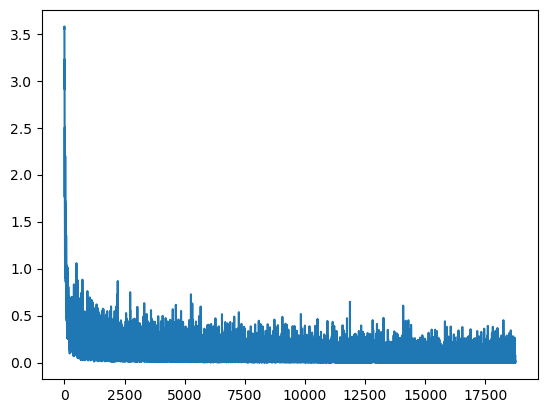

In [319]:
import matplotlib.pyplot as plt

plt.plot([i.item() for i in losses])
plt.show()